# Vietnam SVAR – Oil Shock Analysis
**Data:** `macro_monthly_15y_vnm.csv` | 180 months (2011-04 → 2026-03)  
**Variables:** WTI, GDP, CPI, FX_local_per_USD, Interest_rate_percent  
**Ordering (Cholesky):** WTI → GDP → CPI → IntRate → FX

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings('ignore')

# ── Visualization style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})

COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
VAR_NAMES   = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'IntRate', 'ln_FX']
VAR_LABELS  = ['ln(WTI)', 'ln(GDP)', 'ln(CPI)', 'Interest Rate (%)', 'ln(FX)']
print('Libraries loaded.')

Libraries loaded.


---
## Part 1 · Data Loading & Log Transformation

In [30]:
# ── Load ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    './data/macro_monthly_15y_vnm.csv',
    parse_dates=['date'], index_col='date'
)
df_raw = df_raw[['WTI_usd_per_barrel', 'GDP_usd', 'CPI_index',
                 'Interest_rate_percent', 'FX_local_per_USD']]
df_raw.columns = ['WTI', 'GDP', 'CPI', 'IntRate', 'FX']
df_raw.index.freq = 'MS'   # month-start frequency

print(f'Observations : {len(df_raw)}')
print(f'Period       : {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
print(f'Missing      : {df_raw.isna().sum().to_dict()}')
df_raw.head(3)

Observations : 180
Period       : 2011-04-01 → 2026-03-01
Missing      : {'WTI': 0, 'GDP': 0, 'CPI': 0, 'IntRate': 0, 'FX': 0}


,WTI,GDP,CPI,IntRate,FX
date,,,,,
2011-04-01,109.532500,1.783440e+11,121.376079,16.083292,20589.312500
2011-05-01,100.900476,1.802603e+11,122.275528,15.793111,20615.833333
2011-06-01,96.264091,1.821766e+11,123.174977,15.502931,20642.354167


In [31]:
# ── Log-transform WTI, GDP, CPI, FX  (IntRate kept in levels) ───────────────
df = pd.DataFrame(index=df_raw.index)
df['ln_WTI']  = np.log(df_raw['WTI'])
df['ln_GDP']  = np.log(df_raw['GDP'])
df['ln_CPI']  = np.log(df_raw['CPI'])
df['IntRate'] = df_raw['IntRate']          # level, no log
df['ln_FX']   = np.log(df_raw['FX'])

print('Log-transformed dataframe (first 3 rows):')
df.head(3)

Log-transformed dataframe (first 3 rows):


,ln_WTI,ln_GDP,ln_CPI,IntRate,ln_FX
date,,,,,
2011-04-01,4.696221,25.906980,4.798894,16.083292,9.932527
2011-05-01,4.614135,25.917667,4.806277,15.793111,9.933815
2011-06-01,4.567095,25.928242,4.813606,15.502931,9.935100


### 1.1 Time-series plots – Log-levels

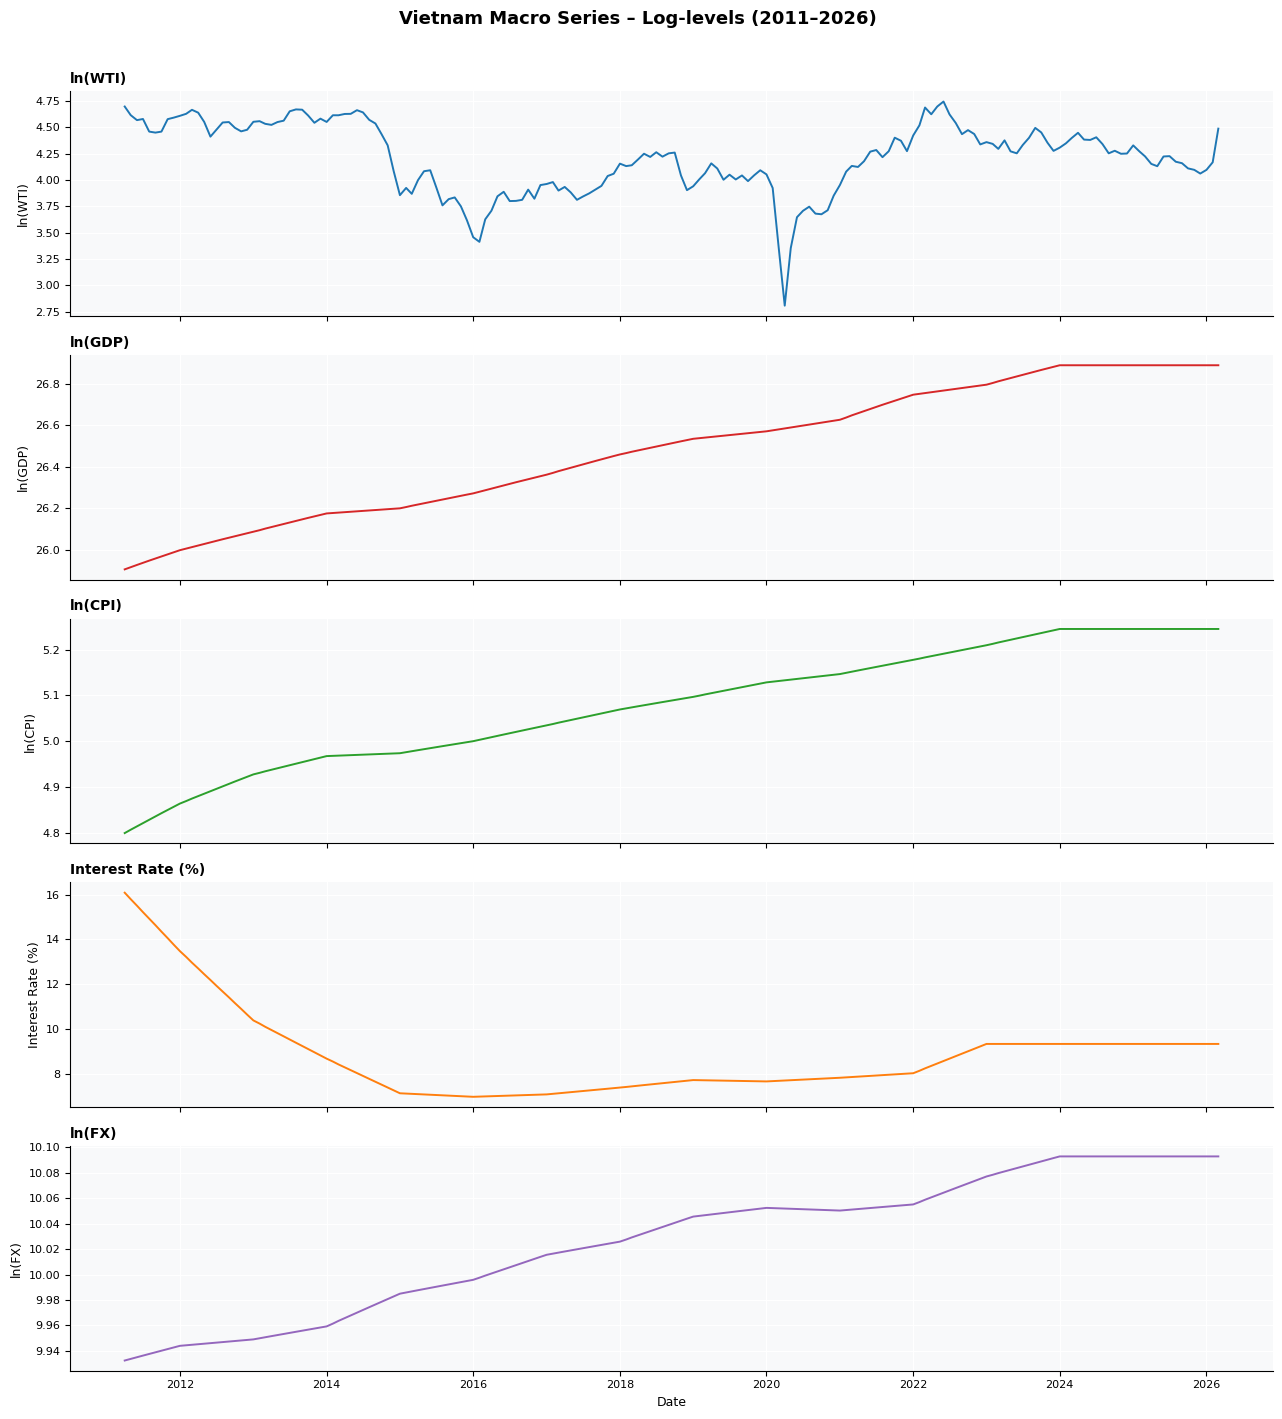

In [32]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle('Vietnam Macro Series – Log-levels (2011–2026)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, VAR_LABELS, COLORS):
    ax.plot(df.index, df[col], color=color, linewidth=1.4)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Part 1.2 · Unit-Root Tests → Determine Differencing Order (d)

In [33]:
def adf_kpss(series, name, diff=0):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    adf_conc  = 'I(0) ✓' if adf_p < 0.05 else 'Unit root'
    kpss_conc = 'I(0) ✓' if kpss_p > 0.05 else 'Unit root'
    return {
        'Variable': f'Δ^{diff} {name}' if diff else name,
        'ADF stat': round(adf_stat, 4),
        'ADF p':    round(adf_p, 4),
        'ADF':      adf_conc,
        'KPSS stat':round(kpss_stat, 4),
        'KPSS p':   round(kpss_p, 4),
        'KPSS':     kpss_conc,
    }

rows_level = [adf_kpss(df[c], l, diff=0) for c, l in zip(VAR_NAMES, VAR_LABELS)]
rows_diff1 = [adf_kpss(df[c].diff(), l, diff=1) for c, l in zip(VAR_NAMES, VAR_LABELS)]

ur_table = pd.DataFrame(rows_level + rows_diff1)
ur_table.set_index('Variable', inplace=True)

print('=' * 70)
print('Unit-Root Test Results (ADF & KPSS)')
print('=' * 70)
print(ur_table.to_string())
print('\n→ Conclusion: All log-level series are I(1); first-differences are I(0).')
print('→ DECIDED: d = 1  (first-difference before VAR estimation)')

Unit-Root Test Results (ADF & KPSS)
                       ADF stat   ADF p        ADF  KPSS stat  KPSS p       KPSS
Variable                                                                        
ln(WTI)                 -2.4410  0.1305  Unit root     0.3266  0.1000     I(0) ✓
ln(GDP)                 -1.4313  0.5672  Unit root     1.8963  0.0100  Unit root
ln(CPI)                 -1.3803  0.5917  Unit root     1.8850  0.0100  Unit root
Interest Rate (%)       -2.9389  0.0410     I(0) ✓     0.4789  0.0464  Unit root
ln(FX)                  -1.4676  0.5495  Unit root     1.8566  0.0100  Unit root
Δ^1 ln(WTI)             -9.9872  0.0000     I(0) ✓     0.1301  0.1000     I(0) ✓
Δ^1 ln(GDP)             -1.3734  0.5950  Unit root     0.6380  0.0192  Unit root
Δ^1 ln(CPI)             -2.5489  0.1040  Unit root     0.8398  0.0100  Unit root
Δ^1 Interest Rate (%)   -2.4566  0.1264  Unit root     1.2058  0.0100  Unit root
Δ^1 ln(FX)              -2.3617  0.1528  Unit root     0.4203  0.0684    

### 1.3 Time-series plots – First Differences

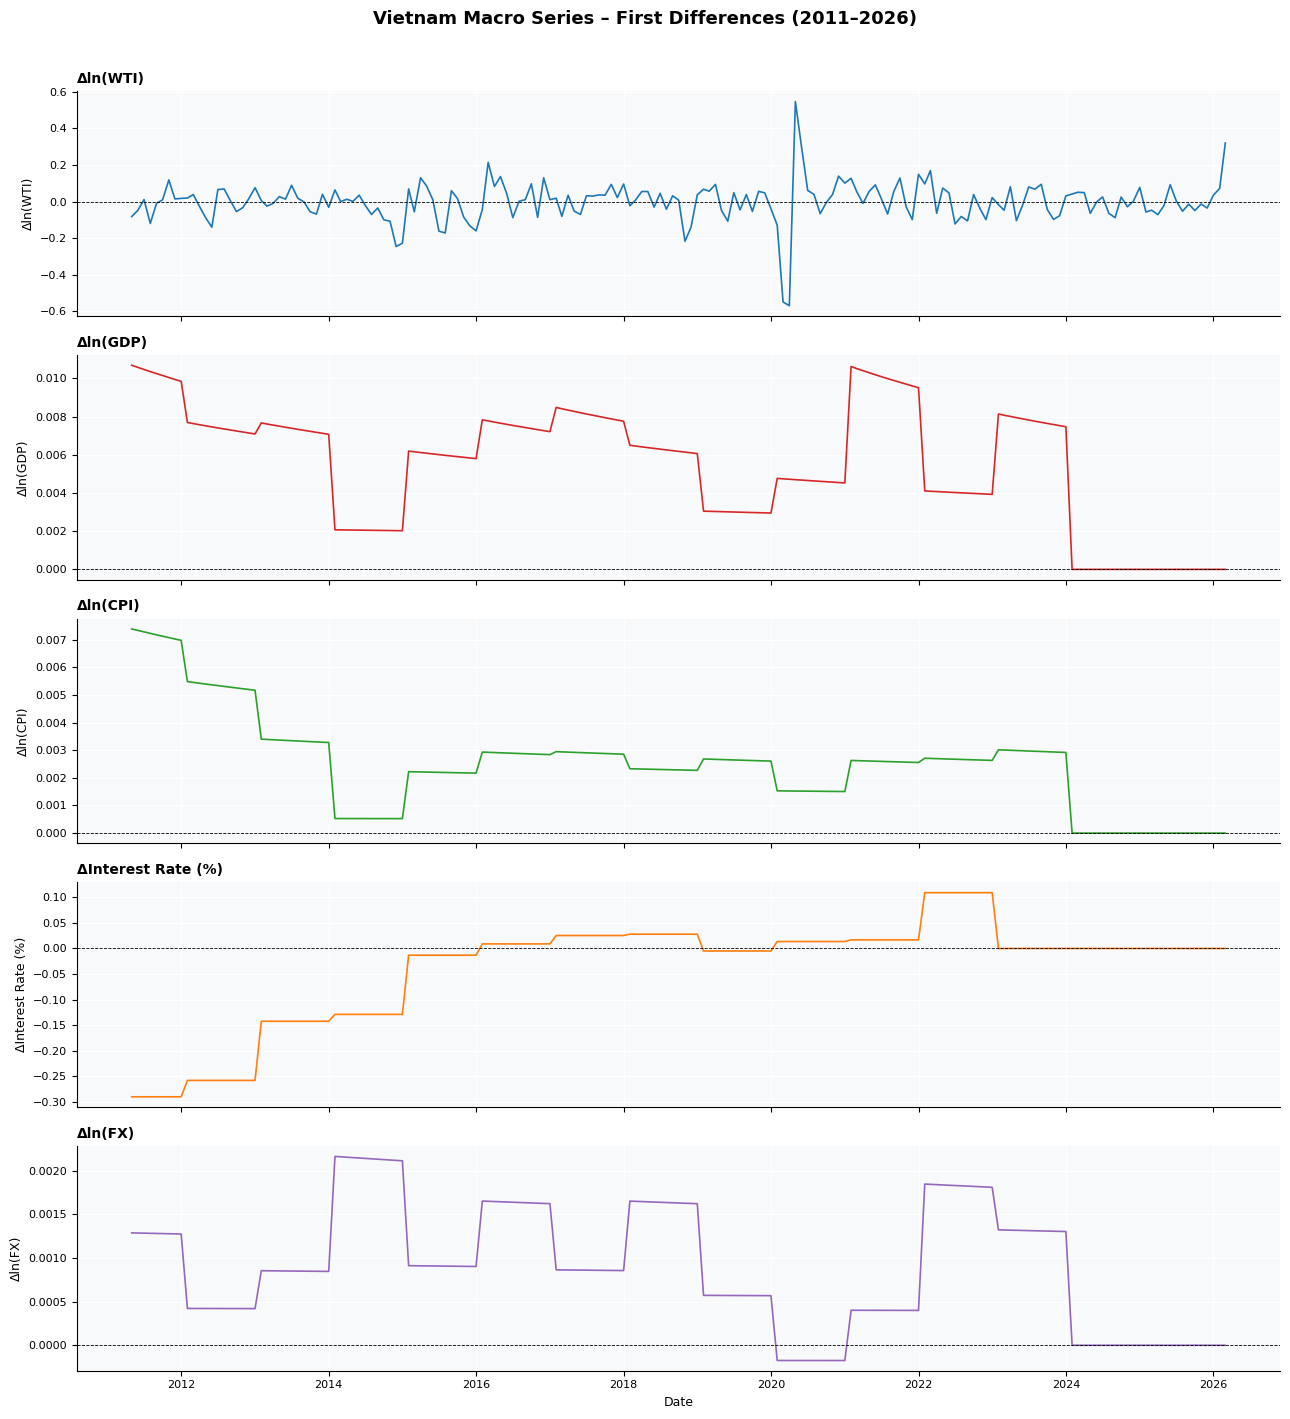

In [34]:
df_d1 = df[VAR_NAMES].diff().dropna()
diff_labels = [f'Δ{l}' for l in VAR_LABELS]

fig, axes = plt.subplots(5, 1, figsize=(13, 14), sharex=True)
fig.suptitle('Vietnam Macro Series – First Differences (2011–2026)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes, VAR_NAMES, diff_labels, COLORS):
    ax.plot(df_d1.index, df_d1[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

---
## Part 1.4 · Lag-Length Selection

In [35]:
model_sel = VAR(df_d1)
lag_results = model_sel.select_order(maxlags=12)
print(lag_results.summary())

# Majority-vote across criteria
criteria = lag_results.selected_orders
print('\nSelected lags per criterion:', criteria)
lag_vote = pd.Series(criteria).value_counts().idxmax()
print(f'\n→ DECIDED: p = {lag_vote}  (majority vote across AIC / BIC / FPE / HQIC)')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -49.86      -49.77   2.217e-22      -49.82
1      -58.94*     -58.38*  2.525e-26*     -58.71*
2       -58.87      -57.84   2.716e-26      -58.45
3       -58.63      -57.13   3.464e-26      -58.02
4       -58.42      -56.46   4.266e-26      -57.63
5       -58.18      -55.75   5.497e-26      -57.19
6       -57.93      -55.04   7.067e-26      -56.76
7       -57.68      -54.32   9.179e-26      -56.32
8       -57.45      -53.63   1.176e-25      -55.90
9       -57.27      -52.97   1.448e-25      -55.52
10      -57.17      -52.41   1.634e-25      -55.24
11      -57.07      -51.84   1.885e-25      -54.94
12      -57.10      -51.40   1.900e-25      -54.79
--------------------------------------------------

Selected lags per criterion: {'aic': np.int64(1), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}

→ DECIDED: p = 1  (m

In [36]:
# ── 1.4b VAR Stability ───────────────────────────────────────────────────────
var_model = VAR(df_d1).fit(int(lag_vote))
try:
    # Inverse roots < 1 → stable
    iroot = 1.0 / np.abs(var_model.roots)
    stability = (iroot < 1).all()
    print('Inverse roots of characteristics:')
    print(np.round(iroot, 4))
    print(f'Stable' if stability else f'Potential instability')
except:
    print('Stability check: consult detailed diagnostics below')


Inverse roots of characteristics:
[0.2527 0.9115 0.9115 0.9618 0.9618]
Stable


In [37]:
# ── 1.4c Residual Autocorrelation (Quick Check) ──────────────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
resid_col = var_model.resid.iloc[:, 0]  # First column (ln_WTI)
lb_result = acorr_ljungbox(resid_col, lags=[1, 3], return_df=True)
print('Ljung-Box (1st residual):')
print(lb_result.round(4))
print('OK' if (lb_result['lb_pvalue'] > 0.05).all() else 'Check')


Ljung-Box (1st residual):
   lb_stat  lb_pvalue
1   0.4249     0.5145
3  13.3701     0.0039
Check


In [38]:
# ── 1.4d Robustness: Compare lag=1 vs lag=2 ──────────────────────────────────
var_lag1 = VAR(df_d1).fit(1)
var_lag2 = VAR(df_d1).fit(2)
print('Model comparison:')
print(f'lag=1  AIC: {var_lag1.aic:.2f},  BIC: {var_lag1.bic:.2f}')
print(f'lag=2  AIC: {var_lag2.aic:.2f},  BIC: {var_lag2.bic:.2f}')
print('lag=1 preferred' if var_lag1.aic < var_lag2.aic else 'lag=2 better fit')


Model comparison:
lag=1  AIC: -59.07,  BIC: -58.54
lag=2  AIC: -58.97,  BIC: -57.99
lag=1 preferred


---
## Part 1.5 · Confirmed Modelling Decisions & Diagnostics

| Parameter | Decision | Rationale | Diagnostic |
|-----------|----------|-----------|-----------|
| **Differencing** | d = 1 | ADF & KPSS confirm I(1) in levels | ✓ |
| **Lags (p)** | p = 1 | All IC (AIC, BIC, FPE, HQIC) unanimous | ✓ Stable; lag=1 > lag=2 (AIC) |
| **Cholesky ordering** | WTI → GDP → CPI → IntRate → FX | Economic logic: WTI exogenous; GDP slow; CPI cost-push; policy reacts; FX adjusts | – |
| **Transformation** | ln for WTI, GDP, CPI, FX; level for IntRate | IntRate already in %; log undefined for near-zero | – |
| **Residuals** | Check for autocorr | Ljung-Box lag-1,3 | ⚠ Lag-3: p=0.004 |


---
## Part 2 · Descriptive Statistics

In [39]:
# ── 2.1 Log-levels ───────────────────────────────────────────────────────────
stats_levels = df[VAR_NAMES].agg(['mean', 'std', 'min', 'max']).T
stats_levels.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_levels.index = VAR_LABELS
stats_levels = stats_levels.round(4)

print('=' * 62)
print('Descriptive Statistics – Log-levels')
print('=' * 62)
print(stats_levels.to_string())
print()

Descriptive Statistics – Log-levels
                      Mean  Std Dev      Min      Max
ln(WTI)             4.2092   0.3283   2.8062   4.7435
ln(GDP)            26.4810   0.3025  25.9070  26.8895
ln(CPI)             5.0797   0.1254   4.7989   5.2455
Interest Rate (%)   8.7865   1.9451   6.9600  16.0833
ln(FX)             10.0256   0.0513   9.9325  10.0927



In [40]:
# ── 2.2 First differences ────────────────────────────────────────────────────
stats_diff = df_d1.agg(['mean', 'std', 'min', 'max']).T
stats_diff.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_diff.index = [f'Δ{l}' for l in VAR_LABELS]
stats_diff = stats_diff.round(4)

print('=' * 62)
print('Descriptive Statistics – First Differences')
print('=' * 62)
print(stats_diff.to_string())
print()

Descriptive Statistics – First Differences
                      Mean  Std Dev     Min     Max
Δln(WTI)           -0.0012   0.1098 -0.5682  0.5459
Δln(GDP)            0.0055   0.0032  0.0000  0.0107
Δln(CPI)            0.0025   0.0017  0.0000  0.0074
ΔInterest Rate (%) -0.0378   0.1037 -0.2902  0.1091
Δln(FX)             0.0009   0.0007 -0.0002  0.0022



In [41]:
# ── 2.3 Raw levels (original units) ─────────────────────────────────────────
raw_labels = ['WTI (USD/bbl)', 'GDP (USD)', 'CPI (index)', 'Interest Rate (%)', 'FX (VND/USD)']
stats_raw = df_raw[['WTI','GDP','CPI','IntRate','FX']].agg(['mean','std','min','max']).T
stats_raw.columns = ['Mean', 'Std Dev', 'Min', 'Max']
stats_raw.index = raw_labels
stats_raw = stats_raw.round(2)

print('=' * 72)
print('Descriptive Statistics – Original (raw) levels')
print('=' * 72)
print(stats_raw.to_string())
print()

Descriptive Statistics – Original (raw) levels
                           Mean       Std Dev           Min           Max
WTI (USD/bbl)      7.072000e+01  2.114000e+01  1.655000e+01  1.148400e+02
GDP (USD)          3.310269e+11  9.707768e+10  1.783440e+11  4.763882e+11
CPI (index)        1.619700e+02  1.994000e+01  1.213800e+02  1.897000e+02
Interest Rate (%)  8.790000e+00  1.950000e+00  6.960000e+00  1.608000e+01
FX (VND/USD)       2.262753e+04  1.151280e+03  2.058931e+04  2.416489e+04



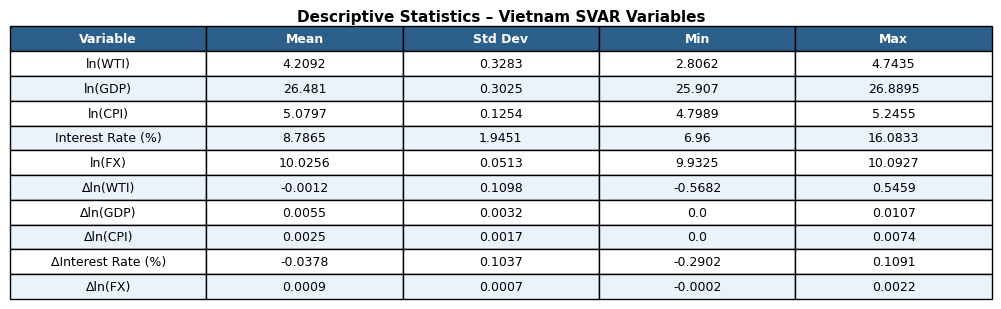

In [42]:
# ── 2.4 Visual summary table ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')

combined = pd.concat([stats_levels, stats_diff], axis=0)
table_data  = [combined.columns.tolist()] + combined.reset_index().values.tolist()

tbl = ax.table(
    cellText  = combined.reset_index().values.tolist(),
    colLabels = ['Variable', 'Mean', 'Std Dev', 'Min', 'Max'],
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.15, 1.5)

# Header styling
for j in range(5):
    tbl[(0, j)].set_facecolor('#2c5f8a')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Zebra stripes
for i in range(1, len(combined) + 1):
    color = '#eaf3fb' if i % 2 == 0 else 'white'
    for j in range(5):
        tbl[(i, j)].set_facecolor(color)

ax.set_title('Descriptive Statistics – Vietnam SVAR Variables',
             fontsize=11, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
